### Распознавание Образов. Алгоритм K внутригрупповых средних.
Братцев А.М. М-Б23. Вариант 2

Дано множество M из 21 образов.


Введите количество кластеров K:  5



 1 шаг
Выбираем случайные 5 стартовых эталонов:
z_1 = [0.03, 0.31]
z_2 = [5.28, 5.26]
z_3 = [-0.32, 0.09]
z_4 = [-1.62, -0.32]
z_5 = [5.53, 5.5]

 ИТЕРАЦИЯ 1
 2 шаг 
w_1 = [[0.03, 0.31], [0.18, -0.31], [0.0, 0.12]]
N_1 = 3
    Пример: точка [0.03, 0.31] -> D = [0.0485, -25.984, -0.037, -1.5112, -28.5446] -> класс 1
w_2 = [[5.28, 5.26]]
N_2 = 1
    Пример: точка [5.28, 5.26] -> D = [1.7405, 27.773, -1.2715, -11.6002, 27.7129] -> класс 2
w_3 = [[-0.32, 0.09], [-0.33, -0.37], [-0.45, 0.63]]
N_3 = 3
    Пример: точка [-0.32, 0.09] -> D = [-0.0302, -28.9892, 0.0553, -0.8738, -31.69] -> класс 3
w_4 = [[-1.62, -0.32], [-0.89, -0.6]]
N_4 = 2
    Пример: точка [-1.62, -0.32] -> D = [-0.1963, -38.0098, 0.4344, 1.3634, -41.1341] -> класс 4
w_5 = [[6.09, 5.83], [5.81, 5.86], [6.14, 5.8], [5.73, 6.17], [5.53, 5.5], [15.2, 4.88], [13.7, 6.55], [14.84, 6.25], [13.85, 6.18], [14.88, 6.26], [13.7, 6.15], [14.66, 5.17]]
N_5 = 12
    Пример: точка [6.09, 5.83] -> D = [1.9415, 35.048, -1.4794, -13.0948, 

Введите координату X для новой точки (или нажмите Enter для X=0):  
Введите координату Y для новой точки (или нажмите Enter для Y=0):  



Значения решающих функций для новой точки [0.0, 0.0]:
  D_1 = -0.0032
  D_2 = -33.0627
  D_3 = -0.0740
  D_4 = -0.8933
  D_5 = -121.2649

Новая точка [0.0, 0.0] отнесена к классу w_1

Построение графиков...


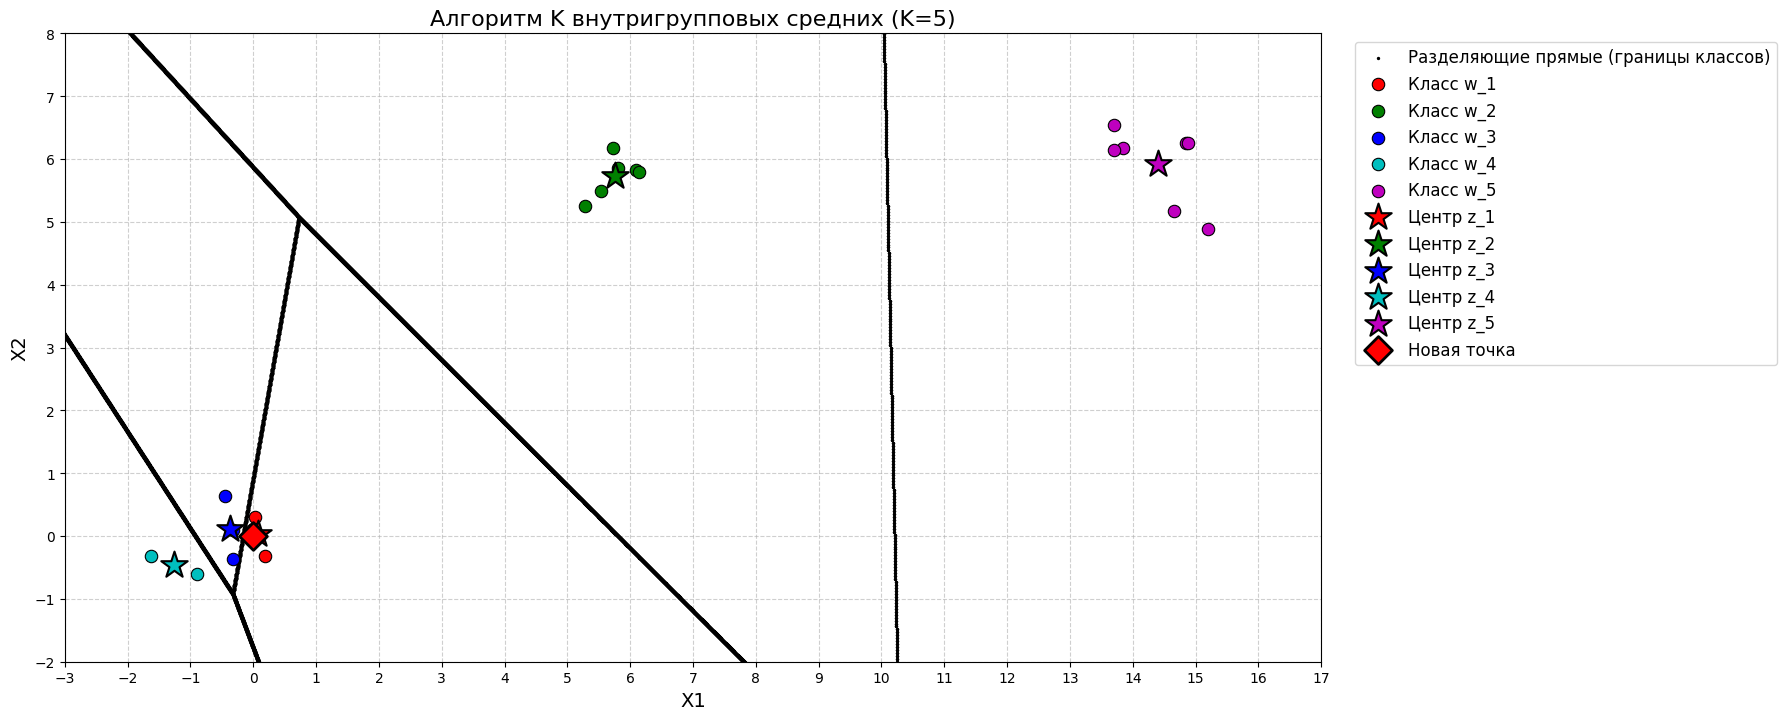

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import random

def linear_g(point, z):
    return point[0] * z[0] + point[1] * z[1] - 0.5 * (z[0]**2 + z[1]**2)

def d(x, Z1, Z2):
    if Z1[1] != Z2[1]:
        return (-(Z1[0] - Z2[0]) * x + (Z1[0] ** 2 + Z1[1] ** 2 - Z2[0] ** 2 - Z2[1] ** 2) / 2) / (Z1[1] - Z2[1])
    else:
        return -((Z1[0] + Z2[0]) / 2)

def classify_by_pairwise_comparison(point, Z):
    K = len(Z)
    D = [linear_g(point, z) for z in Z]
    
    for i in range(K):
        is_maximum = True
        for j in range(K):
            if i != j:
                if D[i] <= D[j]:
                    is_maximum = False
                    break
        if is_maximum:
            return i
    
    return D.index(max(D))

x_str = "5,28	6,09	5,81	6,14	5,73	5,53	15,20	13,70	14,84	13,85	14,88	13,70	14,66	-1,62	0,03	0,18	-0,89	0,00	-0,32	-0,33	-0,45"
y_str = "5,26	5,83	5,86	5,80	6,17	5,50	4,88	6,55	6,25	6,18	6,26	6,15	5,17	-0,32	0,31	-0,31	-0,60	0,12	0,09	-0,37	0,63"

arr_x = list(map(float, x_str.replace(',', '.').split()))
arr_y = list(map(float, y_str.replace(',', '.').split()))
M = [[x, y] for x, y in zip(arr_x, arr_y)]
N = len(M)

print(f"Дано множество M из {N} образов.")

try:
    K = int(input("Введите количество кластеров K: "))
except ValueError:
    K = 3
    print("Некорректный ввод. Установлено K = 3 по умолчанию.")

Z = random.sample(M, K)

print("\n 1 шаг")
print(f"Выбираем случайные {K} стартовых эталонов:")
for i in range(K):
    print(f"z_{i+1} = {Z[i]}")

iteration = 1
while True:
    print(f"\n ИТЕРАЦИЯ {iteration}")

    print(" 2 шаг ")
    W = [[] for _ in range(K)]

    for point in M:
        best_class = classify_by_pairwise_comparison(point, Z)
        W[best_class].append(point)

    for i in range(K):
        w_rounded = [[round(p[0], 2), round(p[1], 2)] for p in W[i]]
        print(f"w_{i+1} = {w_rounded}")
        print(f"N_{i+1} = {len(W[i])}")
        
        if len(W[i]) > 0:
            example_point = W[i][0]
            D_values = [linear_g(example_point, z) for z in Z]
            print(f"    Пример: точка {example_point} -> D = {[round(d, 4) for d in D_values]} -> класс {i+1}")

    print("\n 3 шаг")
    ZZ = []
    for i in range(K):
        if len(W[i]) > 0:
            sum_x = sum(p[0] for p in W[i])
            sum_y = sum(p[1] for p in W[i])
            new_z = [sum_x / len(W[i]), sum_y / len(W[i])]
            ZZ.append(new_z)
        else:
            ZZ.append(Z[i])

    print("Новые пересчитанные Эталоны (zz):")
    for i in range(K):
        print(f"zz_{i+1} = [{ZZ[i][0]:.4f}, {ZZ[i][1]:.4f}]")

    print("\n 4 шаг ")
    changed = False
    for i in range(K):
        if math.hypot(Z[i][0] - ZZ[i][0], Z[i][1] - ZZ[i][1]) > 1e-5:
            changed = True
            break

    if not changed:
        print("Эталоны классов не изменились. Алгоритм завершён.")
        break
    else:
        print("Эталоны кластеров изменились. Переприсваиваем центры:")
        for i in range(K):
            print(f"z_{i+1} = zz_{i+1}")
        Z = ZZ.copy()
        print("И переходим к шагу 2.")
        iteration += 1

print("\n=== Классификация новой точки ===")
try:
    px_input = input("Введите координату X для новой точки (или нажмите Enter для X=0): ")
    py_input = input("Введите координату Y для новой точки (или нажмите Enter для Y=0): ")
    px = float(px_input.replace(',', '.')) if px_input else 0.0
    py = float(py_input.replace(',', '.')) if py_input else 0.0
    new_point = [px, py]
except ValueError:
    new_point = [0.0, 0.0]
    print("Некорректный ввод. Установлена точка по умолчанию: [0.0, 0.0]")

D_new = [linear_g(new_point, z) for z in Z]
print(f"\nЗначения решающих функций для новой точки {new_point}:")
for i in range(K):
    print(f"  D_{i+1} = {D_new[i]:.4f}")

new_point_class = classify_by_pairwise_comparison(new_point, Z)


print(f"\nНовая точка {new_point} отнесена к классу w_{new_point_class + 1}")

print("\nПостроение графиков...")

plt.figure(figsize=(18, 10))
plt.title(f"Алгоритм K внутригрупповых средних (K={K})", fontsize=16)
plt.axis('scaled')

all_points = M + [new_point]
x_min = min(p[0] for p in all_points) - 1
x_max = max(p[0] for p in all_points) + 1
y_min = min(p[1] for p in all_points) - 1
y_max = max(p[1] for p in all_points) + 1

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'pink', 'brown', 'gray', 'olive',
          'deepskyblue', 'greenyellow', 'yellowgreen', 'gold', 'lightcoral', 'lightsalmon']

x_ticks = np.arange(math.floor(x_min), math.ceil(x_max) + 1, 1)
y_ticks = np.arange(math.floor(y_min), math.ceil(y_max) + 1, 1)
plt.xticks(x_ticks)
plt.yticks(y_ticks)

X_range = np.arange(x_min-10, x_max+10, 0.001)
boundary_points = []

for x in X_range:
    for i in range(K):
        for j in range(K):
            if i != j:
                try:
                    result = d(x, Z[i], Z[j])
                    
                    # Проверяем, не вертикальная линия ли это
                    if result < 0 and abs(result + (Z[i][0] + Z[j][0])/2) < 1e-5:
                        # Вертикальная граница
                        vertical_x = -result
                        for y in np.arange(y_min-10, y_max+10, 0.1):
                            xy = [vertical_x, y]
                            ro1 = math.hypot(xy[0] - Z[i][0], xy[1] - Z[i][1])
                            ro2 = math.hypot(xy[0] - Z[j][0], xy[1] - Z[j][1])
                            if abs(ro1 - ro2) < 1e-3:
                                is_valid = True
                                for s in range(K):
                                    if s != i and s != j:
                                        ro3 = math.hypot(xy[0] - Z[s][0], xy[1] - Z[s][1])
                                        if ro3 < min(ro1, ro2) - 1e-5:
                                            is_valid = False
                                            break
                                if is_valid:
                                    boundary_points.append(xy)
                    else:
                        # Обычная наклонная/горизонтальная граница
                        y = result
                        xy = [x, y]
                        ro1 = math.hypot(xy[0] - Z[i][0], xy[1] - Z[i][1])
                        ro2 = math.hypot(xy[0] - Z[j][0], xy[1] - Z[j][1])
                        if abs(ro1 - ro2) < 1e-3:
                            is_valid = True
                            for s in range(K):
                                if s != i and s != j:
                                    ro3 = math.hypot(xy[0] - Z[s][0], xy[1] - Z[s][1])
                                    if ro3 < min(ro1, ro2) - 1e-5:
                                        is_valid = False
                                        break
                            if is_valid:
                                boundary_points.append(xy)
                except ZeroDivisionError:
                    pass

if boundary_points:
    boundary_points = np.array(boundary_points)
    plt.scatter(boundary_points[:, 0], boundary_points[:, 1], c='black', s=2, label='Разделяющие прямые (границы классов)', zorder=2)

for i in range(K):
    if len(W[i]) > 0:
        pts = np.array(W[i])
        plt.scatter(pts[:, 0], pts[:, 1], c=colors[i], label=f'Класс w_{i+1}',
                    edgecolors='black', linewidths=0.8, s=80, zorder=3)

for i in range(K):
    plt.scatter(Z[i][0], Z[i][1], c=colors[i], marker='*', s=400,
                edgecolors='black', linewidths=1.5, zorder=4, label=f'Центр z_{i+1}')

plt.scatter(new_point[0], new_point[1], c=colors[new_point_class], marker='D', s=200,
            edgecolors='black', linewidths=2, zorder=5, label='Новая точка')

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("X1", fontsize=14)
plt.ylabel("X2", fontsize=14)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=12)

plt.tight_layout()
plt.show()